# 04 — Fine-tuning + L1  (SERVER edition)

Self-contained GPU training notebook. Run top to bottom on a **PyTorch + CUDA**
server. It needs only this bundle (src/ + data/scans/crops + template + labels +
preprocess_report). It will:

1. build the seeded **80/20 split** and the **x4-augmented training set**
   (`data/train_recog/`) from the original crops — nothing to upload but the crops;
2. compute the **L0 baseline** (pretrained EasyOCR) over all 100 forms;
3. **fine-tune** the recognizer on the 80 train forms (GPU auto-detected);
4. compute **L1** on the 20 held-out forms and compare L0 vs L1.

**Setup on the server (once):**
```
pip install easyocr pandas        # torch/torchvision already in the image
```
First EasyOCR call downloads the ~64 MB pretrained model (needs internet).

**Download back when done:** `models/easyocr_ft/recognizer.pth`,
`data/generated/predictions_l0.csv`, `data/generated/predictions_l1.csv`.

In [1]:
import sys, torch
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import ocr, finetune

GPU = torch.cuda.is_available()
print("CUDA available:", GPU, "| device:",
      torch.cuda.get_device_name(0) if GPU else "cpu")

CROPS_ROOT  = ROOT / "data" / "scans" / "crops"
FIELD_MAP   = ROOT / "data" / "template" / "field_map.json"
REPORT      = ROOT / "data" / "scans" / "preprocess_report.json"
LABELS      = ROOT / "data" / "scans" / "labels.csv"
SPLIT       = ROOT / "data" / "generated" / "split_train_val.json"
TRAIN_RECOG = ROOT / "data" / "train_recog"
PRED_L0     = ROOT / "data" / "generated" / "predictions_l0.csv"
PRED_L1     = ROOT / "data" / "generated" / "predictions_l1.csv"
CKPT        = ROOT / "models" / "easyocr_ft" / "recognizer.pth"

field_map = ocr.load_field_map(str(FIELD_MAP))
report    = ocr.load_checkbox_report(str(REPORT))
labels    = pd.read_csv(LABELS, dtype=str).fillna("")
labels_by_pid = {r["patient_id"]: dict(r) for _, r in labels.iterrows()}
label_cols = [c for c in labels.columns if c != "image"]
all_pids = sorted(labels_by_pid)

CUDA available: True | device: NVIDIA L40S


In [2]:
# --- Build split + augmented training set on the server (idempotent). -------
AUG_FACTOR = 4
SEED = 42

if SPLIT.exists():
    train_pids, val_pids = finetune.load_split(str(SPLIT))
else:
    train_pids, val_pids = finetune.split_pids(all_pids, train_frac=0.8, seed=SEED)
    finetune.save_split(str(SPLIT), train_pids, val_pids, seed=SEED, train_frac=0.8)
print(f"train {len(train_pids)} / val {len(val_pids)}")

# TEXT-ONLY: digits are handled by the digit CNN (nb 04.1); EasyOCR fine-tunes
# on text fields only. Always rebuilt so a stale digit-containing set can't linger.
stats = finetune.build_recog_dataset(
    str(CROPS_ROOT), field_map, labels_by_pid, train_pids,
    str(TRAIN_RECOG), aug_factor=AUG_FACTOR, seed=SEED, text_only=True)
print("TEXT-ONLY train set:", stats["base_samples"], "base x", AUG_FACTOR,
      "->", stats["images_written"], "imgs")

train 80 / val 20
train_recog: 796 base crops x4 -> 3184 images in /home/jovyan/form-ocr-pipeline/data/train_recog/images
TEXT-ONLY train set: 796 base x 4 -> 3184 imgs


In [3]:
%%time
# --- L0 baseline: pretrained EasyOCR over all 100 forms. --------------------
reader_l0 = ocr.get_reader(gpu=GPU)
rows_l0 = ocr.predict_all(str(CROPS_ROOT), field_map, report,
                          reader=reader_l0, progress=False)
pred_l0 = pd.DataFrame(rows_l0)
for c in label_cols:
    if c not in pred_l0.columns: pred_l0[c] = ""
pred_l0 = pred_l0[label_cols].fillna("")
PRED_L0.parent.mkdir(parents=True, exist_ok=True)
pred_l0.to_csv(PRED_L0, index=False)
print("wrote", PRED_L0)

wrote /home/jovyan/form-ocr-pipeline/data/generated/predictions_l0.csv
CPU times: user 56 s, sys: 1.97 s, total: 58 s
Wall time: 33.1 s


In [4]:
%%time
# --- Fine-tune (guarded). On GPU this is fast; on CPU run overnight. --------
FORCE_RETRAIN = True    # text-only retrain (digits -> CNN); set back to False afterwards
SMOKE         = False   # True -> 1 epoch / 5 batches sanity check

if CKPT.exists() and not FORCE_RETRAIN:
    print("checkpoint exists -> skipping training:", CKPT)
else:
    stats = finetune.train_recognizer(
        out_dir=str(TRAIN_RECOG), ckpt_path=str(CKPT),
        epochs=30, lr=1e-5, batch_size=64, gpu=GPU, smoke=SMOKE)
    print(stats)

train 2864 / val 320 crop samples
epoch 1/30  train 2.4193  val 2.5309  * best, saved
epoch 2/30  train 2.2501  val 2.4217  * best, saved
epoch 3/30  train 2.1534  val 2.3627  * best, saved
epoch 4/30  train 2.0854  val 2.3155  * best, saved
epoch 5/30  train 2.0401  val 2.2825  * best, saved
epoch 6/30  train 2.0153  val 2.2665  * best, saved
epoch 7/30  train 1.9933  val 2.2528  * best, saved
epoch 8/30  train 1.9874  val 2.2462  * best, saved
epoch 9/30  train 1.9774  val 2.2377  * best, saved
epoch 10/30  train 1.9661  val 2.2278  * best, saved
epoch 11/30  train 1.9637  val 2.2298
epoch 12/30  train 1.9561  val 2.2186  * best, saved
epoch 13/30  train 1.9519  val 2.2158  * best, saved
epoch 14/30  train 1.9463  val 2.2111  * best, saved
epoch 15/30  train 1.9439  val 2.2113
epoch 16/30  train 1.9433  val 2.2049  * best, saved
epoch 17/30  train 1.9389  val 2.2000  * best, saved
epoch 18/30  train 1.9328  val 2.1919  * best, saved
epoch 19/30  train 1.9347  val 2.1953
epoch 20/30  

## Fine-tuning loss curve

Train vs. validation CTC loss per epoch. The dashed line / red dot marks the **best** epoch — the one whose weights were actually saved as the checkpoint.

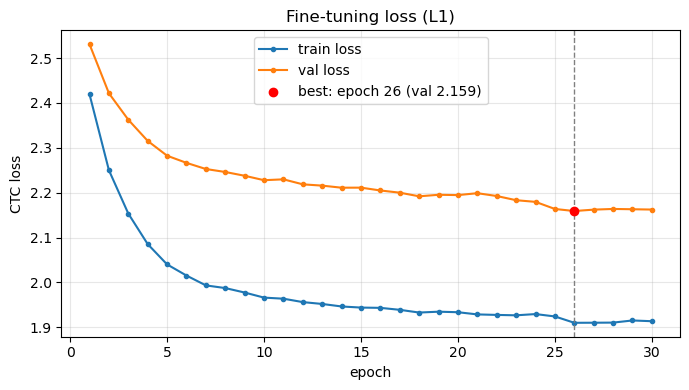

In [5]:
# --- Plot train/val loss and mark the saved (best) epoch. ------------------
import json
import matplotlib.pyplot as plt

with open(CKPT.parent / "history.json") as fh:
    H = json.load(fh)
hist, best = H["history"], H["best_epoch"]
ep = [h["epoch"] for h in hist]
tr = [h["train"] for h in hist]
va = [h["val"]   for h in hist]

plt.figure(figsize=(7, 4))
plt.plot(ep, tr, "-o", ms=3, label="train loss")
plt.plot(ep, va, "-o", ms=3, label="val loss")
if best and 1 <= best <= len(va):
    plt.axvline(best, color="gray", ls="--", lw=1)
    plt.scatter([best], [va[best - 1]], color="red", zorder=5,
                label=f"best: epoch {best} (val {va[best-1]:.3f})")
plt.xlabel("epoch"); plt.ylabel("CTC loss")
plt.title("Fine-tuning loss (L1)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

In [6]:
%%time
# --- L1: fine-tuned recognizer on the 20 held-out forms. -------------------
reader_ft = ocr.get_finetuned_reader(str(CKPT), gpu=GPU)
rows_l1 = ocr.predict_all(str(CROPS_ROOT), field_map, report,
                          reader=reader_ft, pids=val_pids, progress=False)
pred_l1 = pd.DataFrame(rows_l1)
for c in label_cols:
    if c not in pred_l1.columns: pred_l1[c] = ""
pred_l1 = pred_l1[label_cols].fillna("")
pred_l1.to_csv(PRED_L1, index=False)
print("wrote", PRED_L1, "(val forms)")

wrote /home/jovyan/form-ocr-pipeline/data/generated/predictions_l1.csv (val forms)
CPU times: user 13.6 s, sys: 293 ms, total: 13.9 s
Wall time: 7.99 s


In [7]:
# --- L0 vs L1 on the same 20 held-out forms. -------------------------------
def norm(s): return " ".join(str(s).strip().split()).lower()
gt = labels.set_index("patient_id")
l0 = pred_l0.set_index("patient_id"); l1 = pred_l1.set_index("patient_id")
fields = [c for c in label_cols if c != "patient_id"]
val = [p for p in val_pids if p in l0.index and p in l1.index]
def acc(df,f): return 100*sum(norm(gt.loc[p,f])==norm(df.loc[p,f]) for p in val)/len(val)
cmp = pd.DataFrame({"L0_%":{f:acc(l0,f) for f in fields},
                    "L1_%":{f:acc(l1,f) for f in fields}})
cmp["delta"]=(cmp["L1_%"]-cmp["L0_%"]).round(1)
cmp=cmp.round(1).sort_values("delta",ascending=False)
print(f"Per-field exact-match on {len(val)} held-out forms:\n"); print(cmp.to_string())
def micro(df): 
    h=sum(norm(gt.loc[p,f])==norm(df.loc[p,f]) for p in val for f in fields); 
    return 100*h/(len(val)*len(fields))
print(f"\nMACRO  L0 {cmp['L0_%'].mean():.1f}%  ->  L1 {cmp['L1_%'].mean():.1f}%")
print(f"MICRO  L0 {micro(l0):.1f}%  ->  L1 {micro(l1):.1f}%")

Per-field exact-match on 20 held-out forms:

                          L0_%   L1_%  delta
last_name                 15.0   25.0   10.0
medical_history            0.0   10.0   10.0
department                10.0   15.0    5.0
first_name                30.0   35.0    5.0
doctor_name                0.0    5.0    5.0
address                    0.0    0.0    0.0
email                      0.0    0.0    0.0
age                       65.0   65.0    0.0
phone_number               0.0    0.0    0.0
date_of_visit              5.0    5.0    0.0
gender                   100.0  100.0    0.0
blood_type               100.0  100.0    0.0
emergency_contact_name     0.0    0.0    0.0
current_medications        0.0    0.0    0.0
allergies                  5.0    5.0    0.0
date_of_birth              5.0    0.0   -5.0
ssn                       10.0    5.0   -5.0
insurance_number          10.0    0.0  -10.0
chief_complaint           20.0    5.0  -15.0
emergency_contact_phone   20.0    5.0  -15.0

MACRO  L0